# Final Project  

Team 1: ForeCrash

Authors: Andrew Chasteen, Michael Stankiewicz, Ardak Baizhaxynova, Henry Xu, David Forson, Devonte Baity, Heather Northcross

Class: Time Series Forecasting in Python

Date: October 8 2025

A large majority of the code in this notebook is taken directly from the notebooks provided by Professor Tanvir.

### **Abstract**

We forecast the average daily NYC vehicle crashes by month using classical time-series models such as Triple Exponential Smoothing and SARIMA, trained on NYC Open Data (Jan 2021 - Aug 2025). We evaluate the accuracy using rolling backtest windows and report MAPE in the ~8% range. We translate the forecasts into resource allocation guidance for first responder and city agencies by identifying high-risk months / boroughs, which allow them to inform staffing, staging, and prevention operational plans. The end product is a lightweight, transparent approach suitable for our web dashboard, to shift planning from reactive to proactive.


### **Problem Statement & Real-World Motivation**

New York City experiences heavy, seasonal crash patterns with concentrated corridors that repeatedly overwhelm responders. Over-staffing wastes public funds; under-staffing costs lives and delays road clearance. Our question: Can we forecast short-horizon crash counts accurately enough to guide resource allocation?

## Read in the appropriate packages

In [120]:
# These are from Professor Tanvir's Notebook
import matplotlib.pyplot as plt #viz #GUI manager
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from math import sqrt
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm #auto arima
import sklearn.metrics as metrics
import sys
from importlib.metadata import version
import warnings


### Dependency Information

In [121]:
# Print dependency information for repeatability
print(f'Python version used: {sys.version}')
print(f"pandas_datareader version: {version('pandas_datareader')}")
print(f"matplotlib version: {version('matplotlib')}")
print(f"seaborn version: {version('seaborn')}")
print(f"pandas version: {version('pandas')}")
print(f"numpy version: {version('numpy')}")
print(f"statsmodels version: {version('statsmodels')}")
print(f"Scikit-learn version: {version('scikit-learn')}")

Python version used: 3.12.10 (v3.12.10:0cc81280367, Apr  8 2025, 08:46:59) [Clang 13.0.0 (clang-1300.0.29.30)]
pandas_datareader version: 0.10.0
matplotlib version: 3.10.6
seaborn version: 0.13.2
pandas version: 2.3.3
numpy version: 1.26.4
statsmodels version: 0.14.5
Scikit-learn version: 1.7.2


## Import the Data

Reading the downloaded data from https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes

In [122]:
raw_df = pd.read_csv('Motor_Vehicle_Collisions_-_Crashes.csv')

/var/folders/29/f1v5z8bx7gjfz_wsr9h447z80000gn/T/ipykernel_51254/3611014079.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('Motor_Vehicle_Collisions_-_Crashes.csv')


In [123]:
## or import from google share drive

# from google.colab import drive
# drive.mount('/content/drive')

# file_path = "/content/drive/MyDrive/TimeSeries_Final_project/Motor_Vehicle_Collisions_-_Crashes.csv"
# raw_df = pd.read_csv(file_path)

### Visualizing Data

In [124]:
raw_df.tail()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
2208166,09/22/2025,14:30,QUEENS,11357.0,40.795635,-73.825615,"(40.795635, -73.825615)",WHITESTONE BRG,WHITESTONE EXPY,NaN,...,Unspecified,Unspecified,NaN,NaN,4844498,Pick-up Truck,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN
2208167,09/18/2025,13:04,BROOKLYN,11233.0,40.670080,-73.924410,"(40.67008, -73.92441)",NaN,NaN,1610 ST JOHNS PL,...,Unspecified,NaN,NaN,NaN,4844804,Sedan,Motorcycle,NaN,NaN,NaN
2208168,09/19/2025,16:13,BROOKLYN,11210.0,40.616688,-73.948440,"(40.616688, -73.94844)",NaN,NaN,2610 AVENUE N,...,Unspecified,NaN,NaN,NaN,4844813,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2208169,08/22/2025,14:30,BRONX,10453.0,40.855576,-73.907080,"(40.855576, -73.90708)",NaN,NaN,2105 DAVIDSON AVE,...,NaN,NaN,NaN,NaN,4844826,NaN,NaN,NaN,NaN,NaN
2208170,09/22/2025,20:51,QUEENS,11377.0,40.744360,-73.913704,"(40.74436, -73.913704)",51 ST,43 AVE,NaN,...,Unspecified,NaN,NaN,NaN,4844584,Station Wagon/Sport Utility Vehicle,Bike,NaN,NaN,NaN


A quick look at the data shows a lot of information about each crash. However, for the purpose of our problem, the focus will be on predicting the average number of daily crashes by month by borough.

In [125]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208171 entries, 0 to 2208170
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

Inspecting the dataframe info shows almost all the columns are of object type and the index is not a date time index. The Crash Date and Crash Time can be combined to create a date time index.

In [126]:
raw_df['time_index'] = pd.to_datetime(raw_df['CRASH DATE'] + ' ' + raw_df['CRASH TIME'], format = '%m/%d/%Y %H:%M')

In [127]:
df = raw_df.set_index('time_index')

In [128]:
sort_df = df.sort_index()

In [129]:
#creating a simple df with just the accident count of 1 for each accident

simple_sort_df = sort_df.copy()
simple_sort_df['COUNT'] = 1
simple_sort_df_with_borough = simple_sort_df[['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED','BOROUGH']]
simple_sort_df = simple_sort_df.drop(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'], axis=1)


#2207903 entries
print(simple_sort_df.isna().sum())
# COUNT                         0

COUNT    0
dtype: int64


Count is zero indicating no na values

Text(0.5, 0, 'Date')

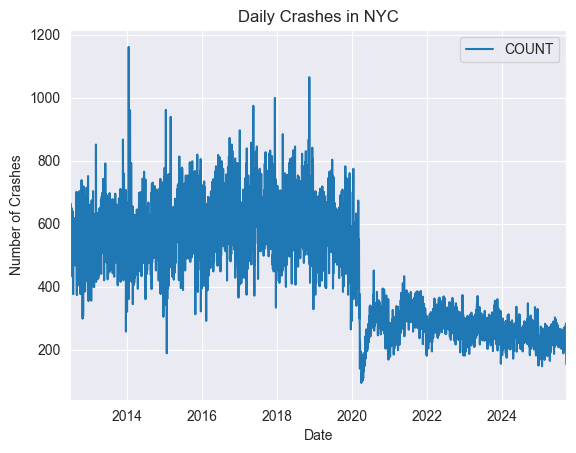

In [130]:
days_simple_sort_df = simple_sort_df.groupby(pd.Grouper(freq='D')).sum()
days_simple_sort_df.plot()
plt.title('Daily Crashes in NYC')
plt.ylabel('Number of Crashes')
plt.xlabel('Date')

Adding the datetime index and a column to track the number of crashes and removing any unnecessary columns, the daily results can be visualized. Notice the significant difference before and after the COVID pandemic. This tool will focus on the data after COVID. Combining all that has been learned into one function the data can be processed.

### Cleaning and Aggregating Data

The below function will do the following: 

- Freshly read the downloaded csv data to avoid conflict with other notebook code
- Assign a datetime column for when the crash happened
- Calculate the number of crashes per day per borough
- Calculate the average of daily crashes per month per borough
- Trim the data to keep only data from after COVID
- Finally, set the index to be a datetime index

In [131]:
def read_clean_data(file):
    raw_df = pd.read_csv(file, low_memory=False)
    raw_df['time_index'] = pd.to_datetime(raw_df['CRASH DATE'] + ' ' + raw_df['CRASH TIME'], format = '%m/%d/%Y %H:%M')
    # 1) Daily crash counts by borough (one row per borough/day)
    daily_counts_borough = (
        raw_df
          .groupby(["BOROUGH", pd.Grouper(key="time_index", freq="D")])
          .size()
          .rename("daily_crashes")
          .reset_index()                       # <-- important so 'time_index' is a column again
    )
    # 2) Monthly average of daily crashes by borough
    monthly_avg_borough = (
        daily_counts_borough
          .groupby(["BOROUGH", pd.Grouper(key="time_index", freq="MS")])  # 'MS' = month start
          ["daily_crashes"].mean()
          .reset_index()
          .rename(columns={"time_index": "month", "daily_crashes": "avg_daily_crashes"})
    )
    # 3) Keep 2021–through last full month 2025-08
    monthly_avg_borough = monthly_avg_borough[
        (monthly_avg_borough["month"] >= "2021-01-01") &
        (monthly_avg_borough["month"] <= "2025-08-31")
    ]
    monthly_avg_borough.set_index('month', inplace=True)
    return monthly_avg_borough

In [132]:
monthly_avg_borough = read_clean_data('Motor_Vehicle_Collisions_-_Crashes.csv')
boro_list = monthly_avg_borough['BOROUGH'].unique()
print(boro_list)

['BRONX' 'BROOKLYN' 'MANHATTAN' 'QUEENS' 'STATEN ISLAND']


In [133]:
monthly_avg_borough.head()

,BOROUGH,avg_daily_crashes
month,,
2021-01-01,BRONX,31.645161
2021-02-01,BRONX,28.821429
2021-03-01,BRONX,33.935484
2021-04-01,BRONX,35.200000
2021-05-01,BRONX,41.322581


The result from processing the data is a dataframe that has a column for the month, a column for the borough, and a column showing the average daily crash for that month for that borough. There are 5 unique boroughs in the dataset. Next, some data integrity will be checked before proceeding.

In [134]:
for boro in boro_list:
    boro_data = monthly_avg_borough[monthly_avg_borough['BOROUGH'] == boro].drop(columns=['BOROUGH'])
    diff_boro = boro_data.index.diff()
    print(f'Borough: {boro}')
    print(diff_boro.max())


Borough: BRONX
31 days 00:00:00
Borough: BROOKLYN
31 days 00:00:00
Borough: MANHATTAN
31 days 00:00:00
Borough: QUEENS
31 days 00:00:00
Borough: STATEN ISLAND
31 days 00:00:00


The max difference is 31 days which indicates no missing months in each of the borough datasets

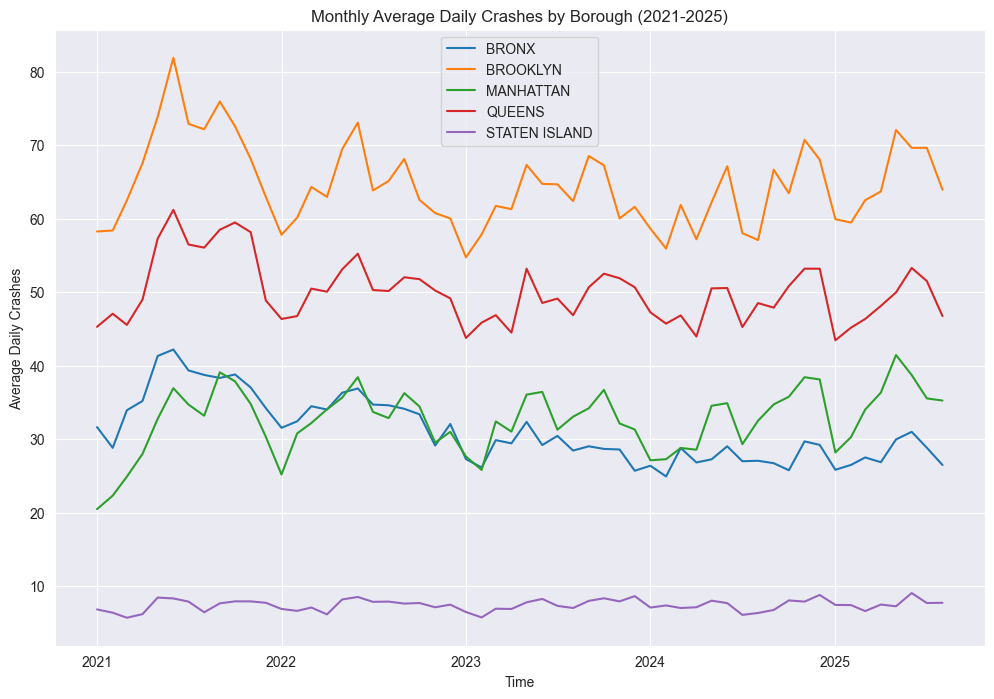

In [135]:
fig, ax = plt.subplots(figsize=(12, 8))
for boro in boro_list:
    boro_data = monthly_avg_borough[monthly_avg_borough['BOROUGH'] == boro]
    ax.plot(boro_data.index, boro_data['avg_daily_crashes'], label=boro)
ax.set_title('Monthly Average Daily Crashes by Borough (2021-2025)')
ax.set_xlabel('Time')
ax.set_ylabel('Average Daily Crashes')
ax.legend()

### Stationarity

Plotting each borough, there appears that Brooklyn consistently has the most crashes daily on average. Next, the data for each borough will be checked for stationarity and differenced if applicable to achieve stationarity. After stationarity is achieved, the ACF and pACF plots will be shown to inform of how much lagged information exists in the time series.

In [136]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """
    Perform ADFuller to test for Stationarity of given series and print report.
    """
    r = adfuller(series.dropna(), autolag='AIC')
    output = {'Test Statistic': round(r[0], 4),
              'p-value': round(r[1], 4),
              '# Lags Used': r[2],
              '# Observations': r[3]}

    print(f'Augmented Dickey-Fuller Test on "{name}"', "\n", '-'*50)
    print(f'Null Hypothesis: Data has unit root (Non-Stationary)')
    print(f'Significance Level: {signif}')
    print(f'Test Statistic: {output["Test Statistic"]}')
    print(f'No. Lags Used: {output["# Lags Used"]}')
    print(f'No. Observations Used: {output["# Observations"]}')

    for key, val in r[4].items():
        print(f'Critical Value {key}: {round(val, 3)}')

    p_value = output['p-value']
    if p_value <= signif:
        print(f"=> P-Value = {p_value}. Rejecting Null Hypothesis.")
        print("=> Series is Stationary.\n")
    else:
        print(f"=> P-Value = {p_value}. Weak evidence to reject Null Hypothesis.")
        print("=> Series is Non-Stationary.\n")


In [137]:
for boro in boro_list:
    boro_data = monthly_avg_borough[monthly_avg_borough['BOROUGH'] == boro]
    boro_data = boro_data.drop(columns=['BOROUGH'])
    adfuller_test(boro_data['avg_daily_crashes'], name=boro)

Augmented Dickey-Fuller Test on "BRONX" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test Statistic: -1.5485
No. Lags Used: 1
No. Observations Used: 54
Critical Value 1%: -3.558
Critical Value 5%: -2.917
Critical Value 10%: -2.596
=> P-Value = 0.5094. Weak evidence to reject Null Hypothesis.
=> Series is Non-Stationary.

Augmented Dickey-Fuller Test on "BROOKLYN" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test Statistic: -2.6923
No. Lags Used: 4
No. Observations Used: 51
Critical Value 1%: -3.566
Critical Value 5%: -2.92
Critical Value 10%: -2.598
=> P-Value = 0.0754. Weak evidence to reject Null Hypothesis.
=> Series is Non-Stationary.

Augmented Dickey-Fuller Test on "MANHATTAN" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test 

The Augmented Dickey-Fuller test was performed for each borough, the results show all boroughs except for Manhattan are non-stationary. The plots and test below explore differencing the data to achieve stationarity and visualize both the partial and regular autocorrelation for each borough.

Augmented Dickey-Fuller Test on "BRONX" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test Statistic: -4.5277
No. Lags Used: 9
No. Observations Used: 32
Critical Value 1%: -3.654
Critical Value 5%: -2.957
Critical Value 10%: -2.618
=> P-Value = 0.0002. Rejecting Null Hypothesis.
=> Series is Stationary.

Augmented Dickey-Fuller Test on "BROOKLYN" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test Statistic: -5.8641
No. Lags Used: 4
No. Observations Used: 37
Critical Value 1%: -3.621
Critical Value 5%: -2.944
Critical Value 10%: -2.61
=> P-Value = 0.0. Rejecting Null Hypothesis.
=> Series is Stationary.

Augmented Dickey-Fuller Test on "MANHATTAN" 
 --------------------------------------------------
Null Hypothesis: Data has unit root (Non-Stationary)
Significance Level: 0.05
Test Statistic: -4.2604
No. Lags Used: 5
No.

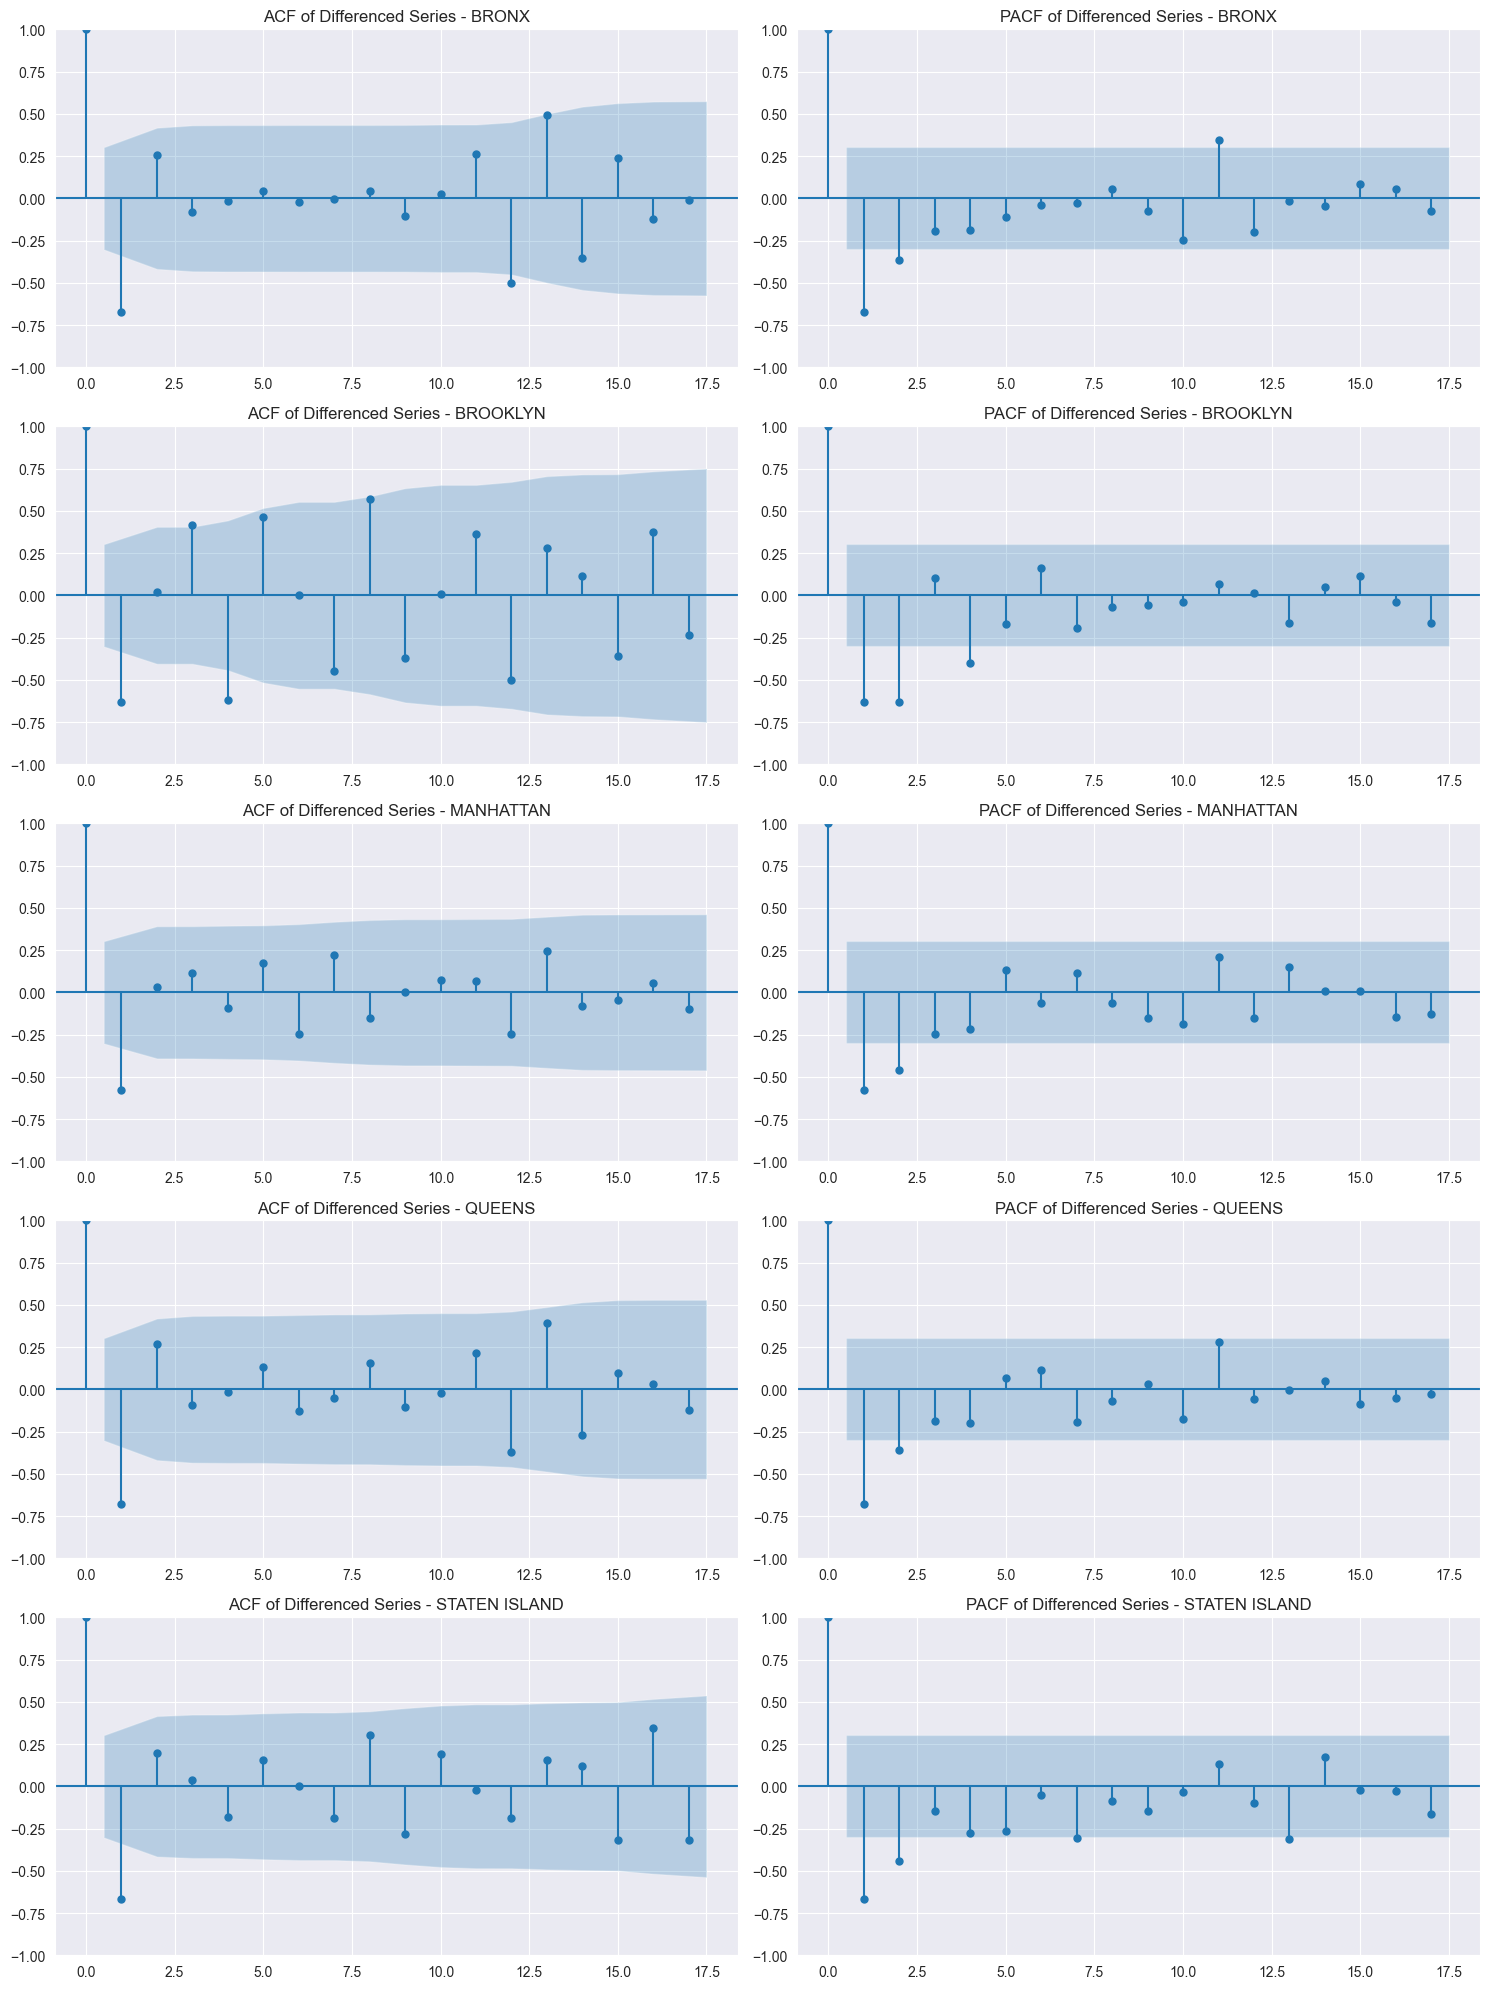

In [138]:
fig, ax = plt.subplots(5, 2, figsize=(15, 20))
for i, boro in enumerate(boro_list):
    boro_data = monthly_avg_borough[monthly_avg_borough['BOROUGH'] == boro]
    boro_data = boro_data.drop(columns=['BOROUGH'])
    diff_boro_data = boro_data.diff().diff().diff(12).dropna()
    adfuller_test(diff_boro_data['avg_daily_crashes'], name=boro)
    plot_acf(diff_boro_data, ax=ax[i, 0], title=f'ACF of Differenced Series - {boro}')
    plot_pacf(diff_boro_data, ax=ax[i, 1], title=f'PACF of Differenced Series - {boro}')
plt.tight_layout()

Second order standard differencing in addition to a single order seasonal differencing was required to achieve stationarity for all boroughs. The resulting ACF and pACF plots show significant information for at least one lags which is good news for our forecasting prospects.

## Modeling

Based on learnings from class, the following models will be used to model the data: 

- ETS model with additive trend and additive seasonality
- ETS model with additive trend and multiplicative seasonality
- Auto-ARIMA model

The function below performs the following:

- Calculates 3 separate test windows.
- Fits the 3 different models for each test window for each borough.
- Results are plotted for each model, test window, and borough.
- The forecasted results for each window, borough, and model are returned for error quantification.

### Backtesting

In [139]:
def backtesting(data, boro_list):
    # BACKTESTING
    fig, ax = plt.subplots(len(boro_list), 3, figsize=(25, 5 * len(boro_list)))
    ets_add_models, ets_add_forecasts = {}, {}
    ets_mul_models, ets_mul_forecasts = {}, {}
    arima_models, arima_forecasts = {}, {}
    test_values = {}
    for j, boro in enumerate(boro_list):
        #--- Target series: monthly crash counts ---
        y = data[data['BOROUGH'] == boro].drop(columns=['BOROUGH'])



        # --- Define test windows ---
        test_periods = [
            ("2023-01-01", "2023-12-01"),
            ("2024-01-01", "2024-12-01"),
            ("2025-01-01", "2025-08-01"),
        ]

        # --- Create rolling train/test splits ---
        splits = []
        for start, end in test_periods:
            start_ts = pd.Timestamp(start)
            end_ts   = pd.Timestamp(end)
            test  = y.loc[start_ts:end_ts]
            train = y.loc[y.index < start_ts]   # all months strictly before test window
            if not train.empty and not test.empty:
                splits.append((train, test))
        for i, (train, test) in enumerate(splits, start=1):
            # ensure monthly frequency
            y_tr = train.astype(float).asfreq('MS')
            y_te = test.astype(float).asfreq('MS')
            h = len(y_te)
            test_values[f'{boro} Actual Values Backtest {i}'] = y_te['avg_daily_crashes']

            # --- Triple ETS (Additive) with damped trend ---
            ets_add = ExponentialSmoothing(
                y_tr, trend="add", 
                seasonal="add", seasonal_periods=12
            ).fit(optimized=True)
            fc_add = ets_add.forecast(h)
            fc_add.index = y_te.index

            ets_add_models[i] = ets_add
            ets_add_forecasts[f'{boro} ETS Additive Backtest {i}'] = fc_add

            # --- Triple ETS (Multiplicative) with damped trend (needs strictly positive data) ---
            ets_mul = ExponentialSmoothing(
                y_tr, trend="add",
                seasonal="mul", seasonal_periods=12
            ).fit(optimized=True)
            fc_mul = ets_mul.forecast(h)
            fc_mul.index = y_te.index
            ets_mul_models[i] = ets_mul
            ets_mul_forecasts[f'{boro} ETS Multiplicative Backtest {i}'] = fc_mul

            with warnings.catch_warnings():
                warnings.simplefilter('ignore')  # ignore statsmodels warnings for cleaner output
                # --- Auto ARIMA ---
                # Note: pmdarima's auto_arima() does not support exogenous variables in seasonal mode
                # (as of version 1.8.5) so we do not include the month dummies here.
                # See
                arima = pm.auto_arima(y_tr,start_p=0, start_q=0,
                                    test='adf',                            # use Augmented Dickey–Fuller test
                                    max_p=3, max_q=3, m=12,                # monthly seasonality (period = 12)
                                    start_P=0, seasonal=True,              # enable seasonal component
                                    d=1, D=1,                   # differencing orders and verbose output
                                    error_action='ignore',
                                    suppress_warnings=True,
                                    stepwise=True)
            fc_arima = arima.predict(n_periods=h)
            fc_arima.index = y_te.index
            arima_models[i] = arima
            arima_forecasts[f'{boro} ARIMA Backtest {i}'] = fc_arima

            # --- Plot (unchanged) ---
            ax[j, i-1].set_title(f"{boro} Backtest Window {i}: {y_te.index[0].strftime('%Y-%m')} → {y_te.index[-1].strftime('%Y-%m')}")
            y.avg_daily_crashes.rename('Full series (context)').plot(color="gray", alpha=0.35, label="Full series (context)", ax= ax[j, i-1])
            y_tr.avg_daily_crashes.rename('Train').plot(color="tab:blue", label="Train", ax= ax[j, i-1])
            y_te.avg_daily_crashes.rename('Test (actual)').plot(color="black", linewidth=2, label="Test (actual)", ax= ax[j, i-1])
            fc_add.plot(color="tab:purple", linewidth=2, label="Forecast (ETS Add)", ax= ax[j, i-1])
            fc_arima.plot(color="tab:green", linewidth=2, label="Forecast (ARIMA)", ax= ax[j, i-1])
            fc_mul.plot(color="tab:orange", linewidth=2, label="Forecast (ETS Mul)", ax= ax[j, i-1])
            ts, te = y_te.index[0], y_te.index[-1]
            ax[j, i-1].axvline(ts, color="gray", linestyle=":", alpha=0.7)
            ax[j, i-1].axvspan(ts, te, color="lightgray", alpha=0.15)
            ax[j, i-1].set_xlabel("Date"); plt.ylabel("Value")
            ax[j, i-1].legend(loc="best")

    plt.tight_layout()
    return (ets_add_forecasts, ets_mul_forecasts, arima_forecasts, test_values)

/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


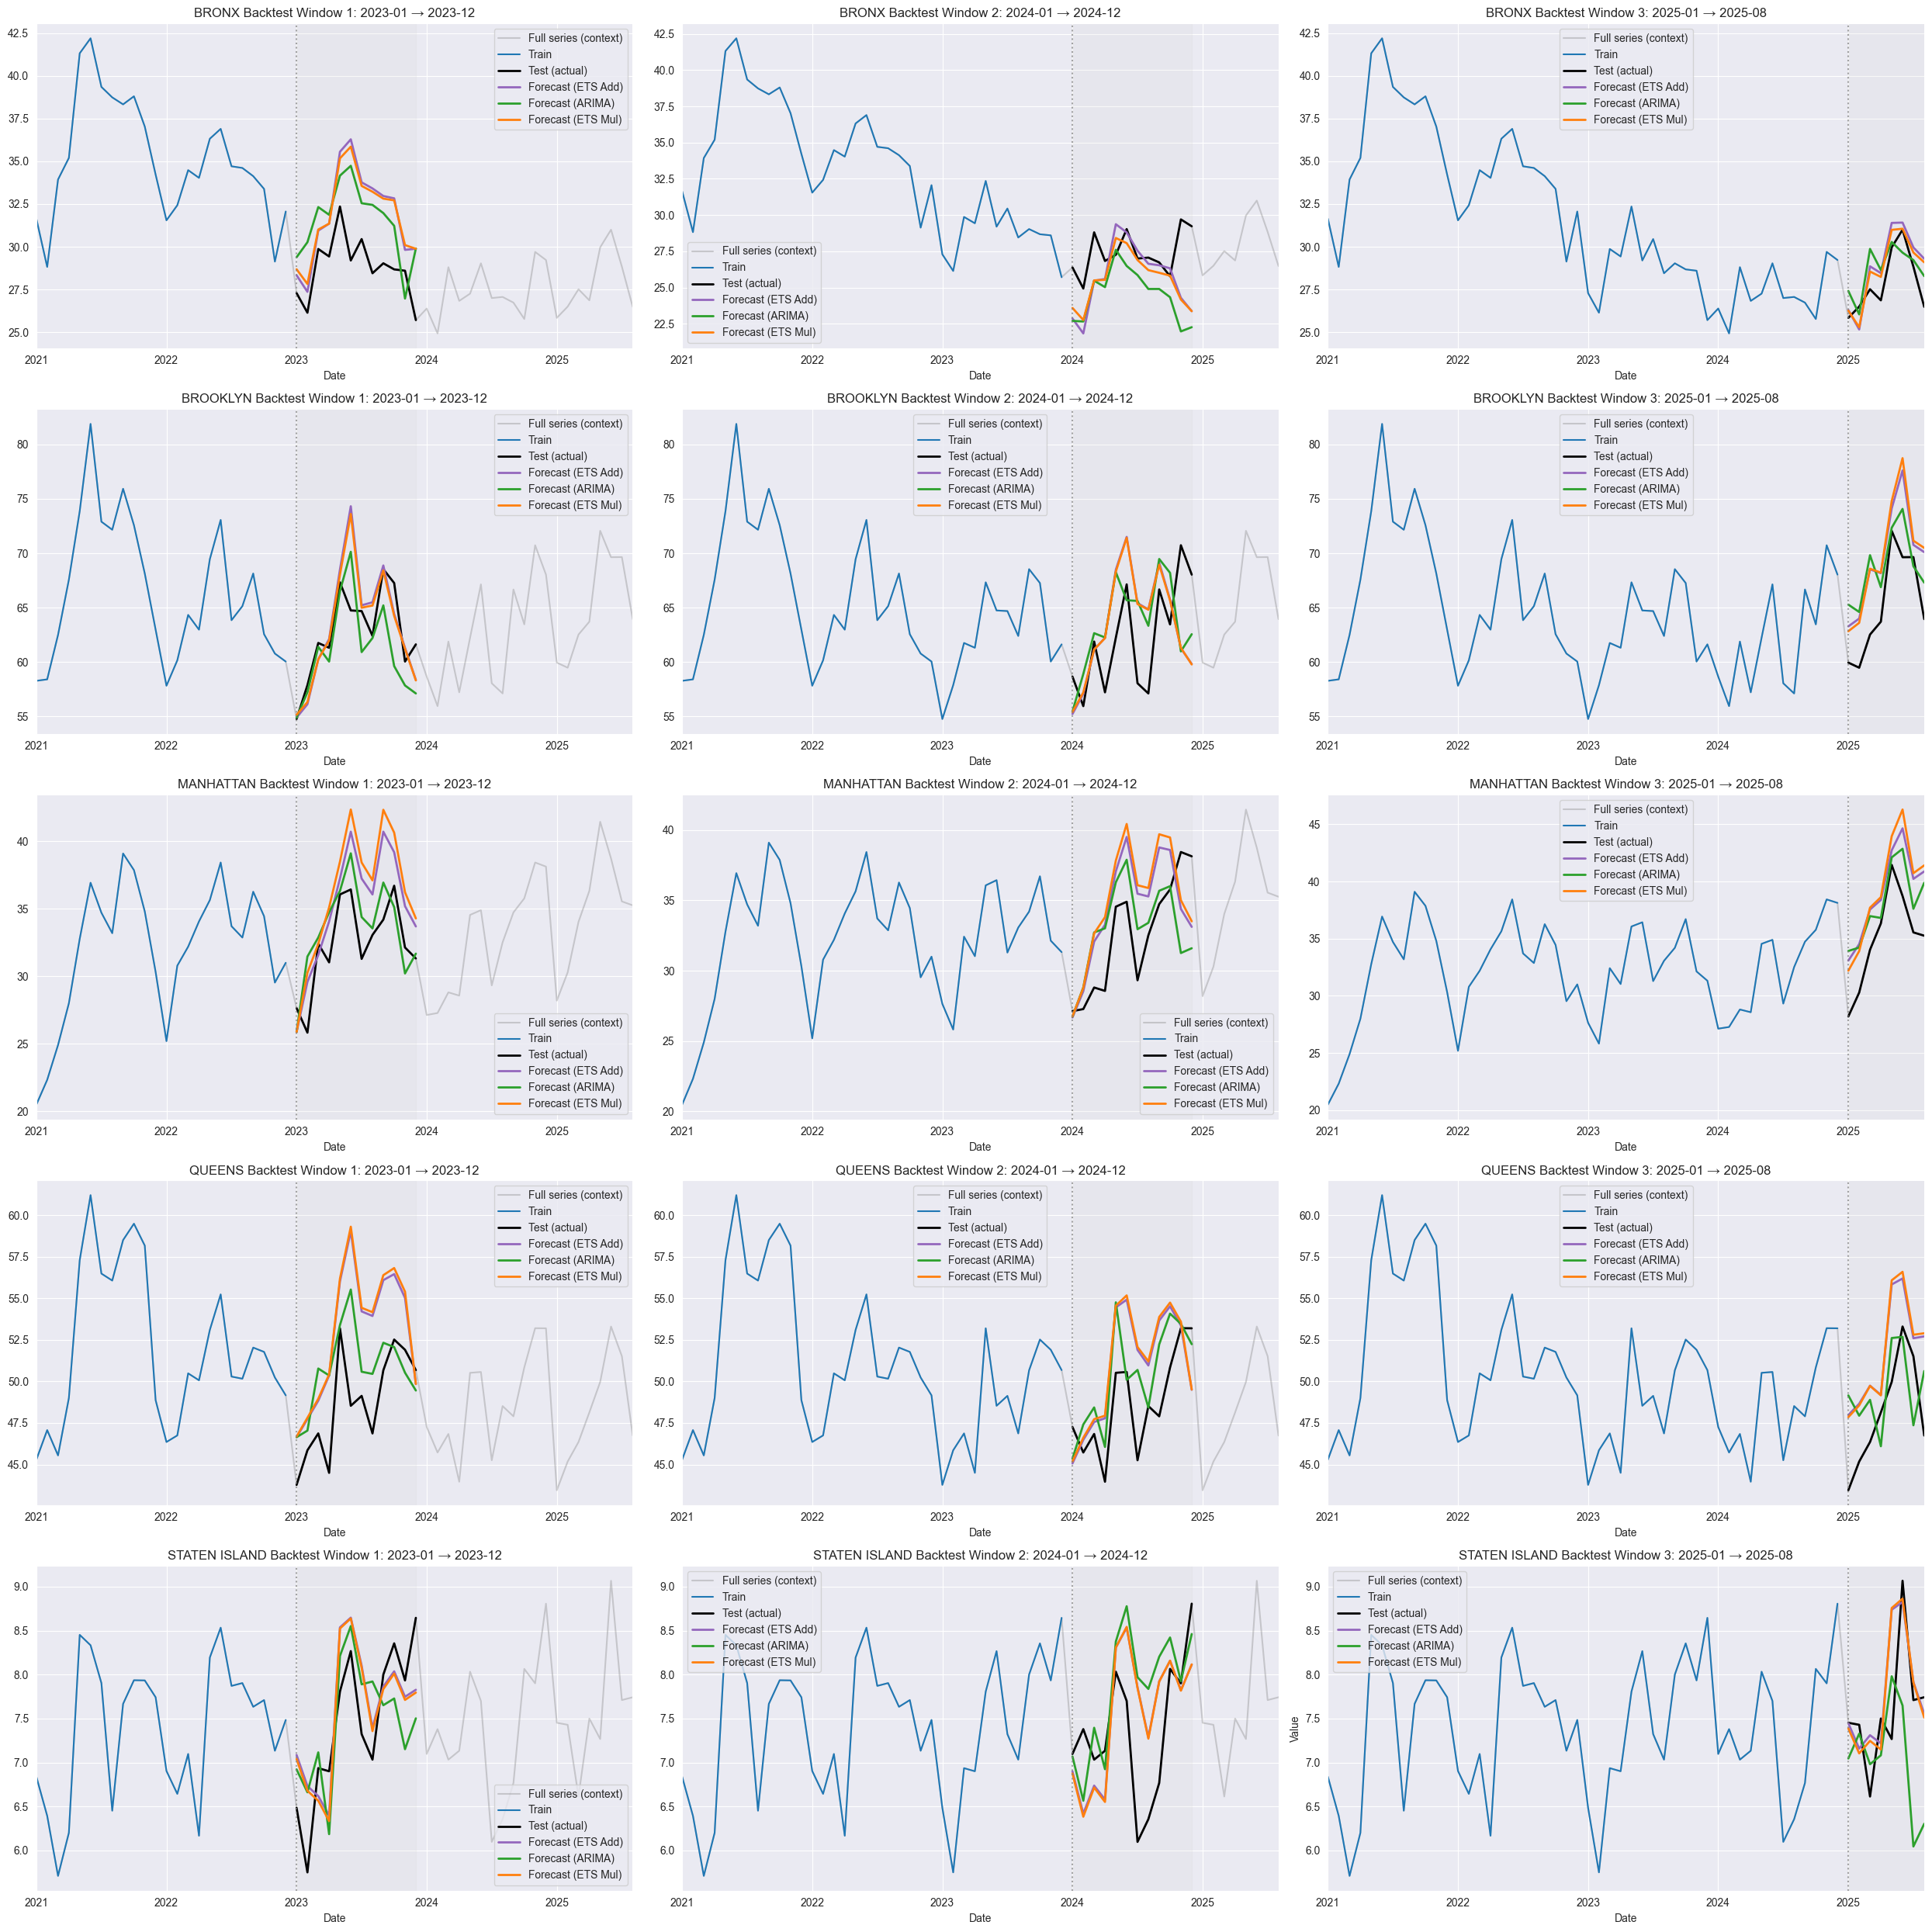

In [140]:
forecast_list = backtesting(monthly_avg_borough, boro_list)

While there is not much visual difference in a lot of the plots, there are some plots where the auto-ARIMA model appears to perform significantly better than the ETS models. The error for each borough and each model can be quantified to give a better idea of model performance.

### Error Quantification

Using the forecast list that was output from the backtesting function, the error can be quantified across the backtest windows for each borough and each model.

First, the data will be parsed into dataframes for each of the backtest windows.

In [141]:
bt1_dict = {}
bt2_dict = {}
bt3_dict = {}

for model in forecast_list:
    for key, value in model.items():
        if 'Backtest 1' in key:
            bt1_dict[key] = value
        elif 'Backtest 2' in key:
            bt2_dict[key] = value
        elif 'Backtest 3' in key:
            bt3_dict[key] = value


In [142]:
bt1_df = pd.DataFrame(bt1_dict)
bt2_df = pd.DataFrame(bt2_dict)
bt3_df = pd.DataFrame(bt3_dict)

In [143]:
bt1_df.head()

,BRONX ETS Additive Backtest 1,BROOKLYN ETS Additive Backtest 1,MANHATTAN ETS Additive Backtest 1,QUEENS ETS Additive Backtest 1,STATEN ISLAND ETS Additive Backtest 1,BRONX ETS Multiplicative Backtest 1,BROOKLYN ETS Multiplicative Backtest 1,MANHATTAN ETS Multiplicative Backtest 1,QUEENS ETS Multiplicative Backtest 1,STATEN ISLAND ETS Multiplicative Backtest 1,BRONX ARIMA Backtest 1,BROOKLYN ARIMA Backtest 1,MANHATTAN ARIMA Backtest 1,QUEENS ARIMA Backtest 1,STATEN ISLAND ARIMA Backtest 1,BRONX Actual Values Backtest 1,BROOKLYN Actual Values Backtest 1,MANHATTAN Actual Values Backtest 1,QUEENS Actual Values Backtest 1,STATEN ISLAND Actual Values Backtest 1
month,,,,,,,,,,,,,,,,,,,,
2023-01-01,28.334332,54.870933,25.870789,46.645121,7.085015,28.685140,55.129192,25.859638,46.684622,7.038998,29.387097,54.870968,25.870968,46.645161,6.921265,27.290323,54.741935,27.645161,43.774194,6.483871
2023-02-01,27.362561,56.106520,29.585668,47.733234,6.731904,27.824242,56.303605,30.263783,47.811283,6.677820,30.267281,57.207373,31.463134,47.040323,6.660896,26.142857,57.857143,25.821429,45.857143,5.750000
2023-03-01,30.947227,60.241859,31.580498,48.838616,6.617275,31.010133,60.235308,32.400918,48.954482,6.564942,32.322581,61.387097,32.870968,50.774194,7.114813,29.870968,61.741935,32.419355,46.870968,6.935484
2023-04-01,31.354221,62.105317,34.065448,50.355812,6.397379,31.355053,61.963758,35.103815,50.421209,6.333538,31.872043,60.031183,34.744086,50.356989,6.184706,29.433333,61.300000,31.033333,44.500000,6.900000
2023-05-01,35.560144,68.499926,37.241819,56.016039,8.536626,35.175861,68.025154,38.493439,56.175510,8.523634,34.161290,66.516129,36.322581,53.387097,8.211588,32.354839,67.322581,36.064516,53.193548,7.806452


Above, is an example of the dataframe created for backtest window 1. This dataframe will be used to calculate the error metrics for each borough and model.

The function below does the following:

1. Accept actual values and predicted values
2. Calculate R2, MSE, MAE, and MAPE
3. Returns a dictionary containing the results of the calculations

Mean Absolute Percentage Error (MAPE) seems to be the best fit for our customers and will be the focus of the analysis.

In [144]:
def calculate_metrics(actuals, predictions):
    # Calculate metrics
    r2 = metrics.r2_score(actuals, predictions)
    mse = metrics.mean_squared_error(actuals, predictions)
    rmse = sqrt(mse)
    mae = metrics.mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    metric_dict = {'R2':r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    return metric_dict

In [145]:
print(boro_list)

['BRONX' 'BROOKLYN' 'MANHATTAN' 'QUEENS' 'STATEN ISLAND']


In [146]:
bt1_MAPE = pd.DataFrame(columns=['Borough','ETS Additive', 'ETS Multiplicative', 'ARIMA'])
bt2_MAPE = pd.DataFrame(columns=['Borough','ETS Additive', 'ETS Multiplicative', 'ARIMA'])
bt3_MAPE = pd.DataFrame(columns=['Borough','ETS Additive', 'ETS Multiplicative', 'ARIMA'])
metrics_dict = {'BT1':(bt1_df, bt1_MAPE), 'BT2': (bt2_df, bt2_MAPE), 'BT3': (bt3_df, bt3_MAPE)}

for metric in metrics_dict.values():
    for boro in boro_list:
        actual  = metric[0].filter(regex=f'{boro} Actual Values').values
        etsA  = metric[0].filter(regex=f'{boro} ETS Additive').values
        etsM  = metric[0].filter(regex=f'{boro} ETS Multiplicative').values
        arimaE  = metric[0].filter(regex=f'{boro} ARIMA').values
        metric[1].loc[len(metric[1])] = [boro, calculate_metrics(actual, etsA)['MAPE'], calculate_metrics(actual, etsM)['MAPE'], calculate_metrics(actual, arimaE)['MAPE']]
    metric[1].set_index('Borough', inplace=True)


In the code above, dataframes are instantiated for each of the backtest windows where the MAPE calculation will be stored for each borough and model. The resulting dataframes are shown below.

In [147]:
bt1_MAPE.head()

,ETS Additive,ETS Multiplicative,ARIMA
Borough,,,
BRONX,10.808266,10.748473,10.538344
BROOKLYN,3.458048,3.219693,3.909781
MANHATTAN,9.949201,12.635084,6.707262
QUEENS,8.853307,9.220963,5.432520
STATEN ISLAND,7.103015,7.141034,8.291294


In [148]:
bt2_MAPE.head()

,ETS Additive,ETS Multiplicative,ARIMA
Borough,,,
BRONX,7.938613,7.362996,10.498205
BROOKLYN,7.791481,7.691055,7.518470
MANHATTAN,10.593623,11.907650,8.672740
QUEENS,6.592801,6.896168,4.589344
STATEN ISLAND,9.383808,9.495698,10.141857


In [149]:
bt3_MAPE.head()

,ETS Additive,ETS Multiplicative,ARIMA
Borough,,,
BRONX,4.782537,3.918010,4.558598
BROOKLYN,6.918069,7.230695,5.928797
MANHATTAN,11.846225,12.609730,9.310517
QUEENS,7.451908,7.634753,6.468382
STATEN ISLAND,5.755884,5.980966,10.450981


Next, the 3 backtest windows MAPE calculations will be averaged to provide a single MAPE calculation per model and borough.

In [150]:
avg_bt_MAPE = (bt1_MAPE + bt2_MAPE + bt3_MAPE) / 3

In [151]:
avg_bt_MAPE.head()

,ETS Additive,ETS Multiplicative,ARIMA
Borough,,,
BRONX,7.843139,7.343160,8.531716
BROOKLYN,6.055866,6.047148,5.785683
MANHATTAN,10.796350,12.384155,8.230173
QUEENS,7.632672,7.917294,5.496749
STATEN ISLAND,7.414236,7.539233,9.628044


(0.0, 12.5)

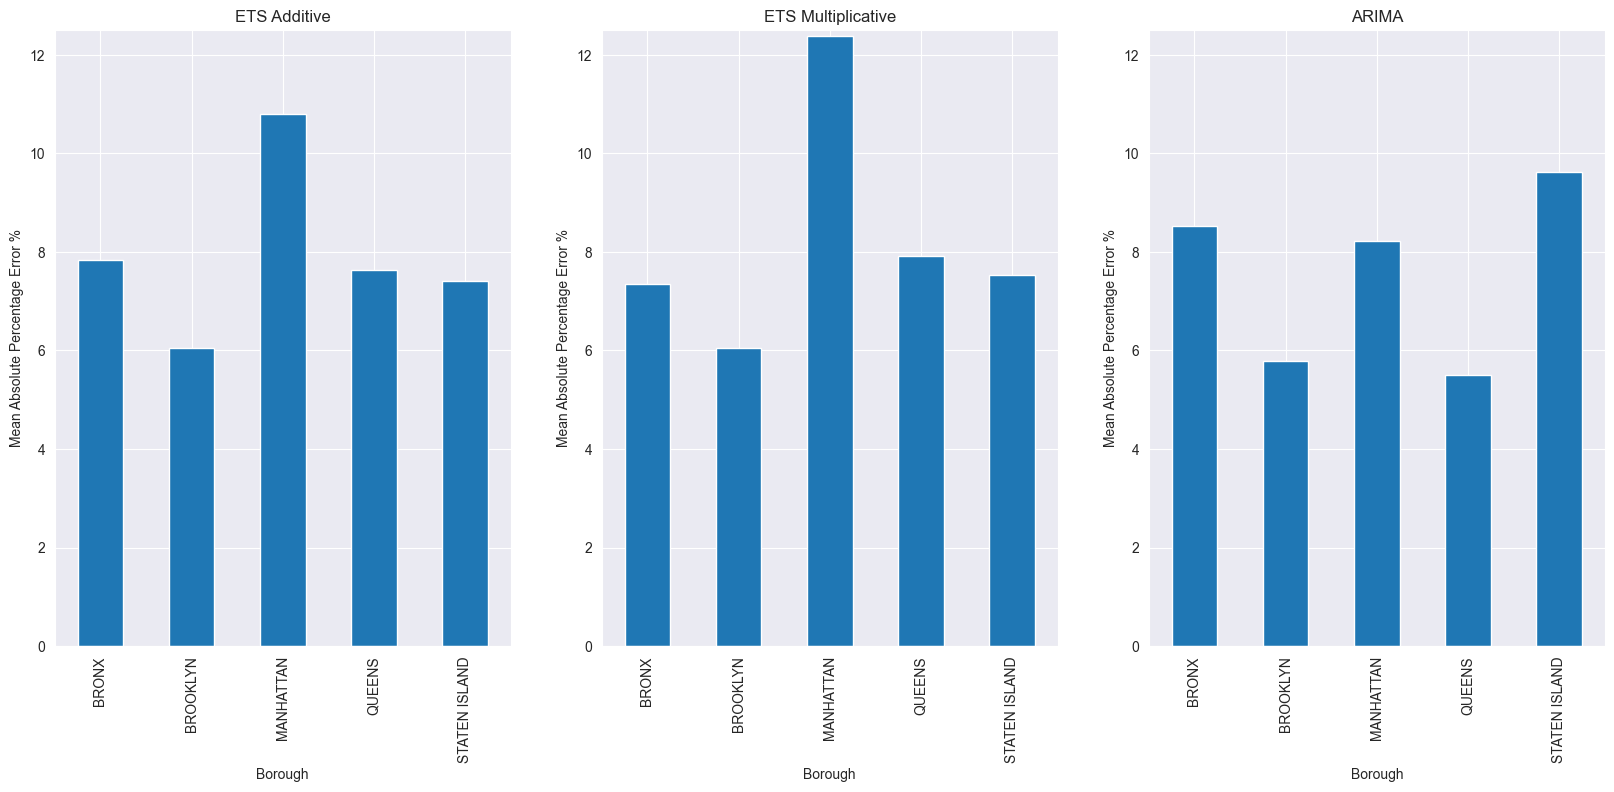

In [152]:
fig, ax = plt.subplots(1, 3 , figsize=(20, 8))
avg_bt_MAPE['ETS Additive'].plot(ax=ax[0], kind='bar')
avg_bt_MAPE['ETS Multiplicative'].plot(ax=ax[1], kind='bar')
avg_bt_MAPE['ARIMA'].plot(ax=ax[2], kind='bar')
ax[0].set_ylabel('Mean Absolute Percentage Error %')
ax[1].set_ylabel('Mean Absolute Percentage Error %')
ax[2].set_ylabel('Mean Absolute Percentage Error %')
ax[0].set_title('ETS Additive')
ax[1].set_title('ETS Multiplicative')
ax[2].set_title('ARIMA')
ax[0].set_ylim(0, 12.5)
ax[1].set_ylim(0, 12.5)
ax[2].set_ylim(0, 12.5)


The MAPE performance for each model and borough can be visualized above. For the ETS models, there is a notable peak in error for Manhattan while the other boroughs are more consistent. Comparing the ETS to the ARIMA model, there is a notable lack of peak for Manhattan, indicating that ARIMA performs better across the boroughs.

## Model Ranking

Averaging the MAPE calculation for all the boroughs yields an average MAPE score for each model that can be used to rank the models relative to each other.

In [153]:
avg_MAPE = avg_bt_MAPE.mean()
avg_MAPE.name = 'Average'
avg_MAPE.sort_values(ascending=False, inplace=True)
avg_MAPE.head()

ETS Multiplicative    8.246198
ETS Additive          7.948452
ARIMA                 7.534473
Name: Average, dtype: float64

Text(0.5, 1.0, 'ARIMA Performs Best')

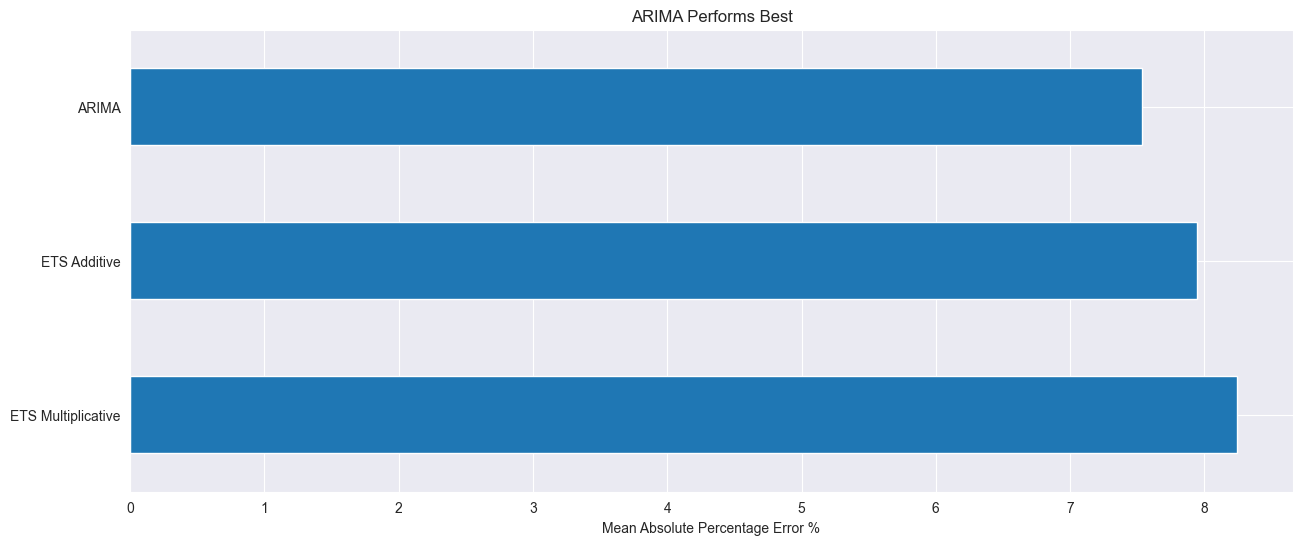

In [154]:
plt.figure(figsize=(15, 6))
avg_MAPE.plot(x=avg_MAPE.index, y='Average', kind='barh')
plt.xlabel('Mean Absolute Percentage Error %')
plt.title('ARIMA Performs Best')

The results of the ranking can be visualized above. As suggested in the previous by borough plot, ARIMA shows the best (lowest) MAPE. However, all models seem to perform pretty closely to each other.

## Conclusion

Averaged across boroughs and backtest windows, the mean absolute percent error shows approximately 8% for each of the three models. Across models, the accuracy for Brooklyn appears to be the best around 6%.

Manhattan shows higher error around 12% for the ETS models, but is resolved when forecasted using the ARIMA model.

### Final Prediction

Finally, using all the data available currently, forecasts about the future avg daily crashes for the next year will be generated with bands for +/- 8% to account for the potential error.

The functions below extracted from the backtesting function and will be used to generate the models for all of the available data

In [155]:
def ets_additive_forecast(df, periods):
    model = ExponentialSmoothing(df, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()
    forecast = model.forecast(periods)
    return forecast

def ets_multiplicative_forecast(df, periods):
    model = ExponentialSmoothing(df, trend='add', seasonal='mul', seasonal_periods=12, freq='MS').fit()
    forecast = model.forecast(periods)
    return forecast

def arima_forecast(df, periods):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')  # ignore statsmodels warnings for cleaner output
        model = pm.auto_arima(
        df,  # your training series
        start_p=0, start_q=0,
        test='adf',                            # use Augmented Dickey–Fuller test
        max_p=3, max_q=3, m=12,                # monthly seasonality (period = 12)
        start_P=0, seasonal=True,              # enable seasonal component
        d=1, D=1,                  # differencing orders and verbose output
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True)
    forecast = model.predict(n_periods=periods)
    return forecast

The function below will generate forecasts for a specified borough and model. This function was extracted from the web app backend.

In [162]:
def forecast_boro(clean_df, borough, model_option, periods, ele_num):
    borough_df = clean_df[clean_df['BOROUGH'] == borough.upper()]
    borough_df = borough_df.drop('BOROUGH', axis=1)
    borough_df.index = pd.to_datetime(borough_df.index)
    if model_option == "ETS Additive":
        forecast = ets_additive_forecast(borough_df, periods)
    elif model_option == "ETS Multiplicative":
        forecast = ets_multiplicative_forecast(borough_df, periods)
    elif model_option == "ARIMA":
        forecast = arima_forecast(borough_df, periods)
    else:
        forecast = None
    forecast.index = pd.date_range(start=forecast.index.min(), periods=periods, freq='MS')
    return forecast

Using the defined functions, forecasts for each borough and each model are generated

In [177]:
etsa_line_dict = {}
etsm_line_dict = {}
arima_line_dict = {}
for boro in boro_list:
    etsa_line_dict[boro] = forecast_boro(monthly_avg_borough, boro, 'ETS Additive', 12, 1)
    etsm_line_dict[boro] = forecast_boro(monthly_avg_borough, boro, 'ETS Multiplicative', 12, 1)
    arima_line_dict[boro] = forecast_boro(monthly_avg_borough, boro, 'ARIMA', 12, 1)

/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/drewchasteen/Documents/CMU/Forecasting/Final_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


The results are assigned to dataframes for plotting

In [178]:
etsa_line_df = pd.DataFrame(etsa_line_dict)
etsm_line_df = pd.DataFrame(etsm_line_dict)
arima_line_df = pd.DataFrame(arima_line_dict)
etsa_line_df.head()


,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
2025-09-01,26.962186,70.654666,38.835555,50.303247,8.083485
2025-10-01,26.565141,67.297861,38.962104,51.681427,8.582948
2025-11-01,26.020495,65.755297,36.485459,51.403207,8.291815
2025-12-01,25.210328,64.000361,35.454043,48.504085,8.736172
2026-01-01,22.758689,58.603506,29.759496,43.157581,7.593562


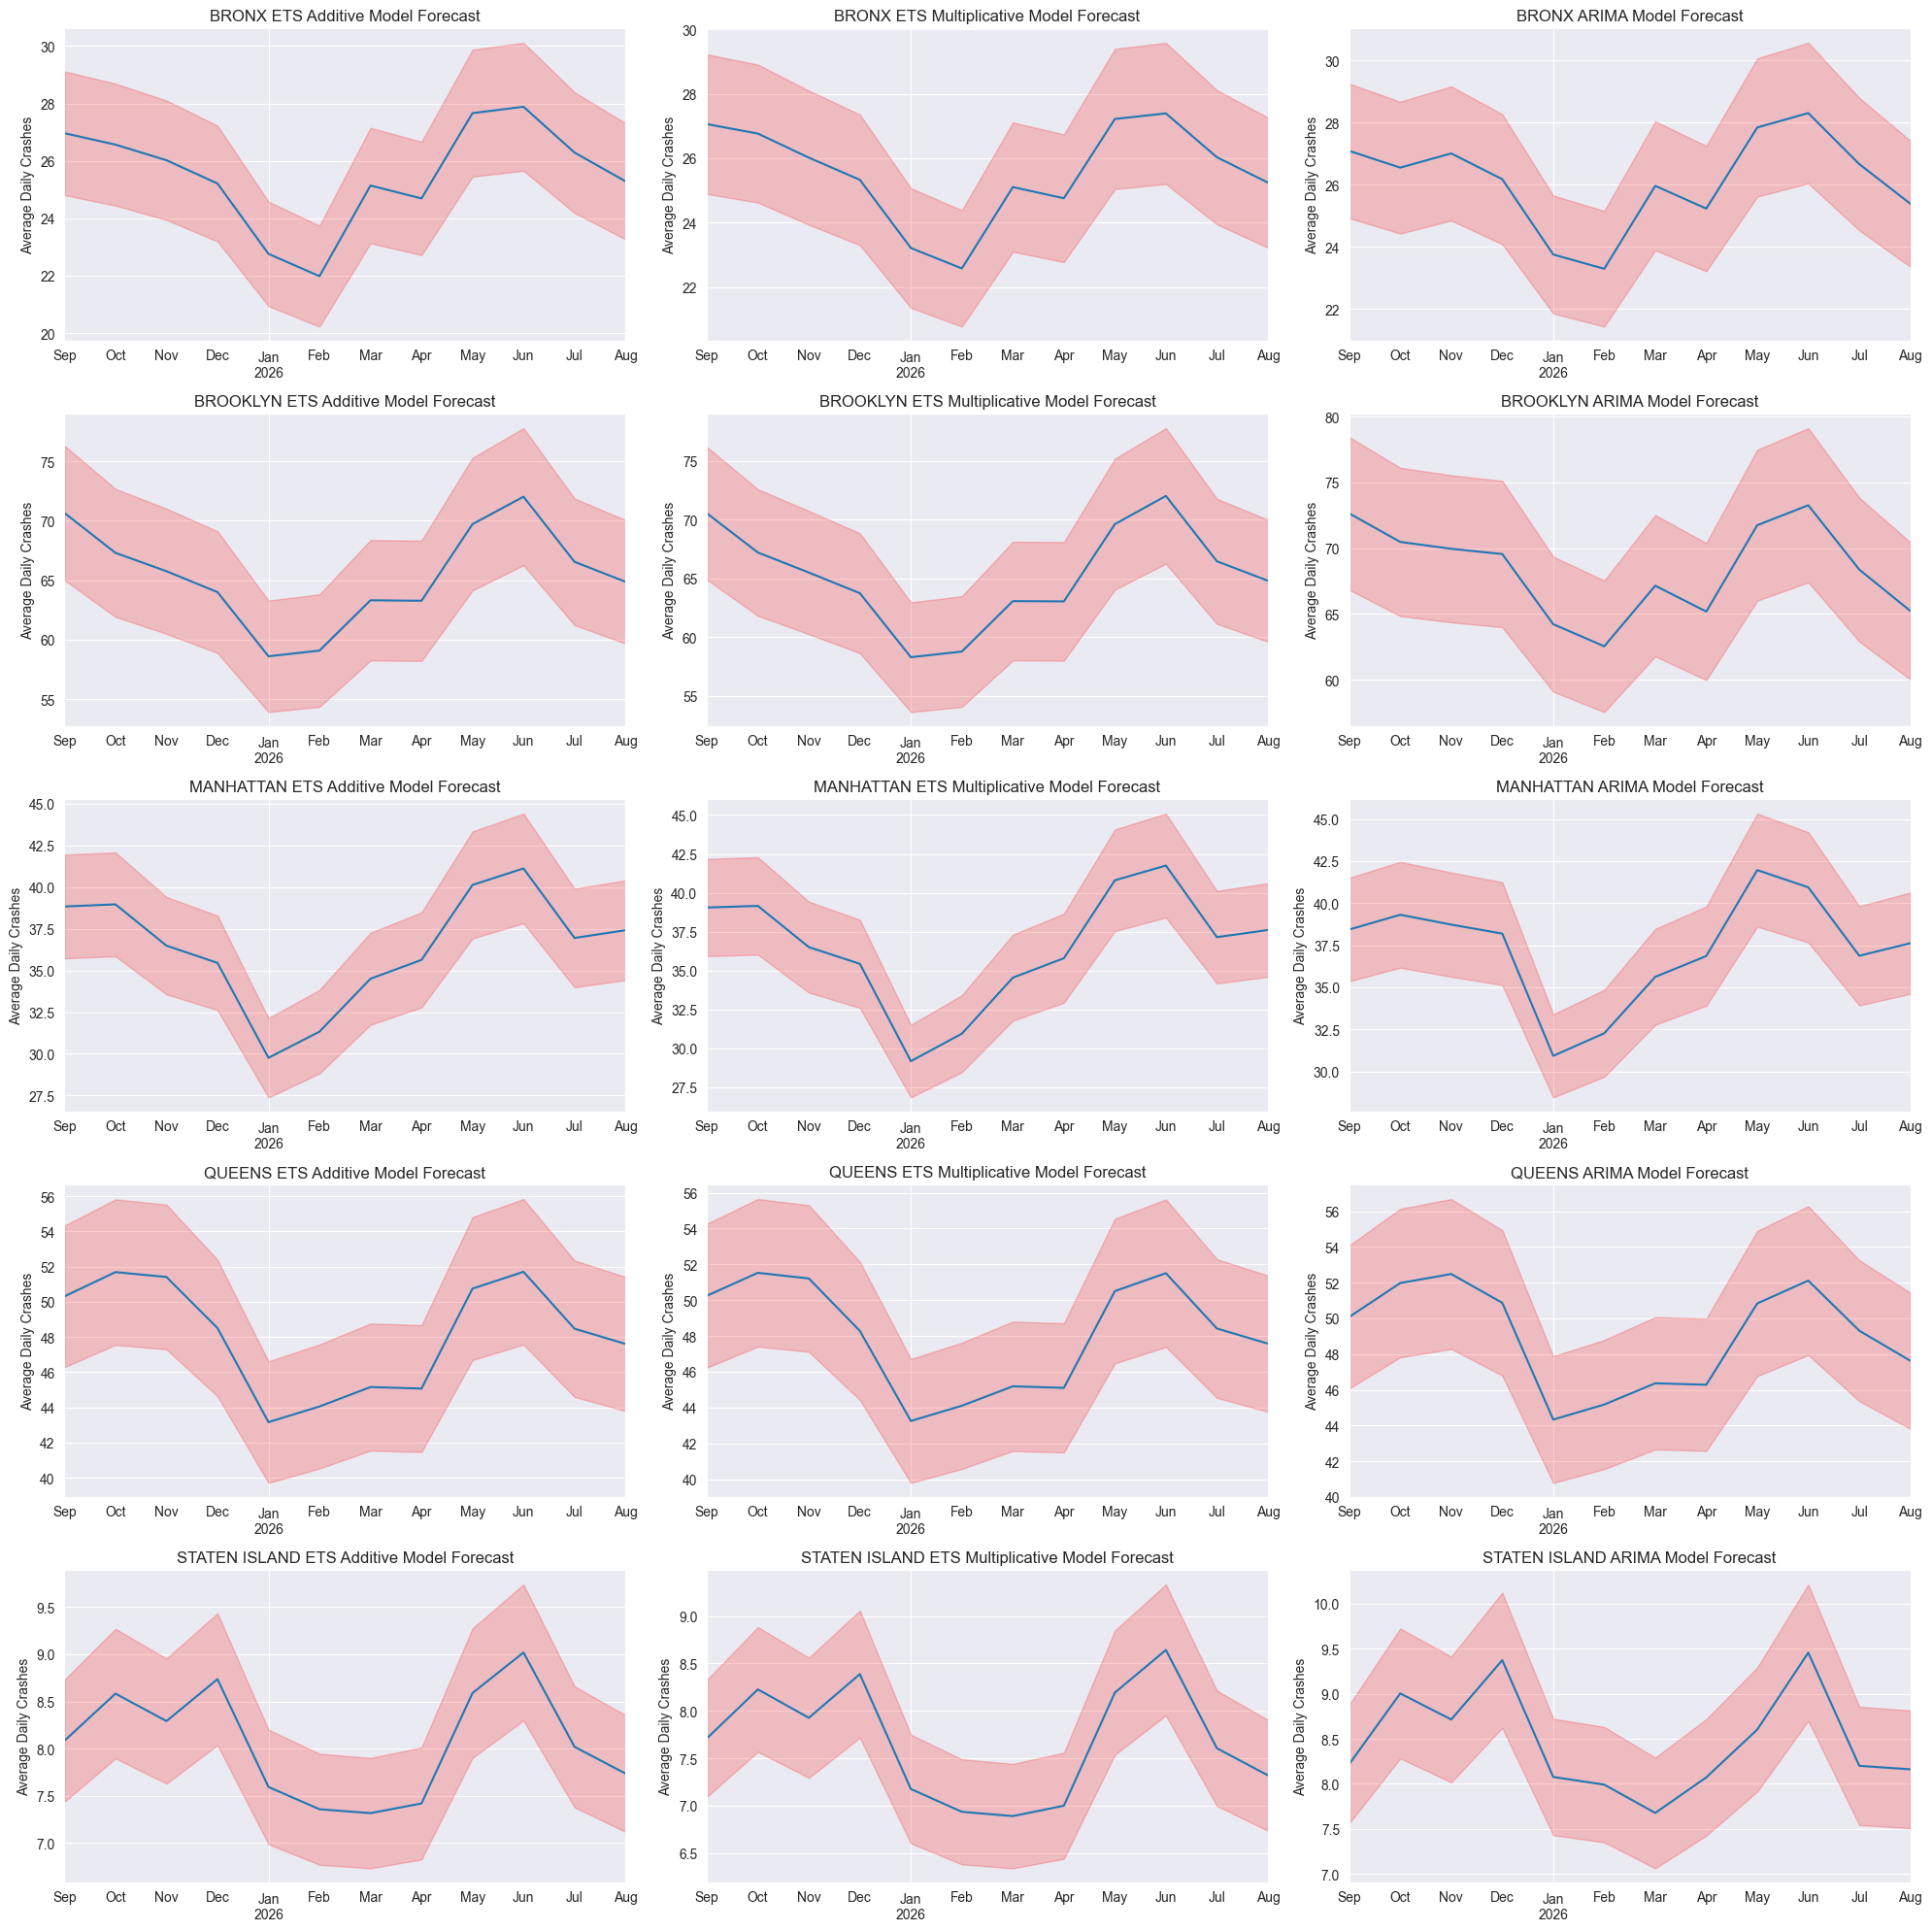

In [180]:
fig, ax = plt.subplots(5, 3, figsize=(20, 20))
for i, boro in enumerate(boro_list):
    etsa_line_df[boro].plot(ax=ax[i, 0])
    ax[i,0].fill_between(etsa_line_df.index,etsa_line_df[boro]*0.92,etsa_line_df[boro]*1.08,color='red',alpha=0.2, label=f'Forecast CI (based on 8% MAPE)')
    ax[i,0].set_ylabel('Average Daily Crashes')
    ax[i,0].set_title(f'{boro} ETS Additive Model Forecast')

    etsm_line_df[boro].plot(ax=ax[i, 1])
    ax[i,1].fill_between(etsm_line_df.index,etsm_line_df[boro]*0.92,etsm_line_df[boro]*1.08,color='red',alpha=0.2, label=f'Forecast CI (based on 8% MAPE)')
    ax[i,1].set_ylabel('Average Daily Crashes')
    ax[i,1].set_title(f'{boro} ETS Multiplicative Model Forecast')

    arima_line_df[boro].plot(ax=ax[i, 2])
    ax[i,2].fill_between(arima_line_df.index,arima_line_df[boro]*0.92,arima_line_df[boro]*1.08,color='red',alpha=0.2, label=f'Forecast CI (based on 8% MAPE)')
    ax[i,2].set_ylabel('Average Daily Crashes')
    ax[i,2].set_title(f'{boro} ARIMA Model Forecast')
plt.tight_layout()

A forecast using all available data is provided for each borough and each model type. A confidence band is provided aligning with the 8% MAPE calculated in the error quantification section. The resulting forecasts with error bounds are useful to the customer as it is able to differentiate the need for each month.

### Key Takeaways

The learnings can be summarized as follows:

1. Using classical forecasting methods, the average daily crashes in New York City for a given month and be usefully forecasted.
2. ARIMA models seem to perform slightly better than Exponential Smoothing models.
3. Models perform forecasts with approximately 8% mean absolute error.